# NexusAI — LangGraph + Groq + Tavily

**Reviewed & corrected Agentic AI implementation.**

| Package | Min Version |
|---|---|
| `langgraph` | 0.2.0+ |
| `langchain` | 0.3.0+ |
| `langchain-core` | 0.3.0+ |
| `langchain-groq` | 0.2.0+ |
| `langchain-tavily` | 0.1.0+ |
| `python-dotenv` | 1.0.0+ |

```bash
pip install langgraph langchain langchain-core langchain-groq langchain-community langchain-tavily tavily-python python-dotenv
```

---

**Graphs built here:**
- **Part 1** — Basic Chatbot: `START → LLM → END`
- **Part 2** — Single-shot Tool Call: `START → LLM → TOOLS → END`
- **Part 3** — ReAct Loop: `START → LLM ↔ TOOLS → END`

---

### Fixes applied over original code

| # | Original | Fixed | Reason |
|---|---|---|---|
| 1 | `model="openai/gpt-oss-20b"` | `model="llama-3.3-70b-versatile"` | Not a real Groq model ID |
| 2 | `TavilySearch(max_result=2)` | `TavilySearch(max_results=2)` | Typo — param is `max_results` (plural) |
| 3 | `{"messages": "raw string"}` | `{"messages": [HumanMessage(...)]}` | Explicit role assignment; required for reliable tool calling |
| 4 | Only checked `GROQ_API_KEY` | Also checks `TAVILY_API_KEY` | TavilySearch needs its own API key |
| 5 | Scattered imports throughout cells | All imports at top | Best practice; easier to debug |
| 6 | `llm_with_tool` (singular) | `llm_with_tools` (plural) | Consistent with `tools` list name |
| 7 | Typo `"llmchabot"` | `"llmchatbot"` | Typo fix in node name |

## Imports & Environment Setup

In [1]:
# ── Standard library ──────────────────────────────────────────────────────────
import os
from typing import Annotated
from typing_extensions import TypedDict

# ── LangChain / LangGraph ─────────────────────────────────────────────────────
from langchain_core.messages import HumanMessage        # FIX 3: explicit message type
from langchain_groq import ChatGroq
from langchain_tavily import TavilySearch

from langgraph.graph import StateGraph, START, END
from langgraph.graph.message import add_messages
from langgraph.prebuilt import ToolNode, tools_condition

# ── Utilities ─────────────────────────────────────────────────────────────────
from dotenv import load_dotenv
from IPython.display import Image, display

In [2]:
load_dotenv()

# FIX 4: check both keys — original only checked GROQ_API_KEY
for key in ("GROQ_API_KEY", "TAVILY_API_KEY"):
    if os.getenv(key):
        print(f"{key} loaded successfully.")
    else:
        print(f"ERROR: {key} not found in environment.")

GROQ_API_KEY loaded successfully.
TAVILY_API_KEY loaded successfully.


## State Definition

`add_messages` is a reducer that **appends** new messages to the list rather than overwriting it.
This is what enables conversation history across multiple LLM calls.

In [3]:
class State(TypedDict):
    messages: Annotated[list, add_messages]

## LLM Initialization

**FIX 1:** Original used `model="openai/gpt-oss-20b"` which is **not a valid Groq model**.

Valid Groq model IDs (as of 2025-2026):
- `llama-3.3-70b-versatile` ← used here (best balance of speed + capability)
- `llama3-70b-8192`
- `llama-3.1-8b-instant`
- `mixtral-8x7b-32768`
- `gemma2-9b-it`

In [4]:
# FIX 1: "openai/gpt-oss-20b" is not a Groq model — replaced with valid Groq model ID
llm = ChatGroq(model="llama-3.3-70b-versatile")

---
## Part 1 — Basic Agent
### Graph: `START → llmchatbot → END`

In [5]:
def chatbot(state: State):
    return {"messages": [llm.invoke(state["messages"])]}


graph_builder = StateGraph(State)

# FIX 7: typo "llmchabot" → "llmchatbot"
graph_builder.add_node("llmchatbot", chatbot)
graph_builder.add_edge(START, "llmchatbot")
graph_builder.add_edge("llmchatbot", END)

graph = graph_builder.compile()

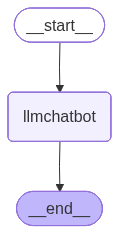

In [6]:
try:
    display(Image(graph.get_graph().draw_mermaid_png()))
except Exception:
    pass

### Test: `graph.invoke()`

**FIX 3:** Passing `"Hi nexa"` (a raw string) → wrapped in `[HumanMessage(content=...)]`.

Why: `add_messages` *can* coerce a raw string to a `HumanMessage`, but the role assignment
is not guaranteed across all LLM providers. Using `HumanMessage` explicitly sets `role="user"`,
which is required for correct chat history and tool calling.

In [7]:
# FIX 3: use HumanMessage instead of a raw string
response = graph.invoke({"messages": [HumanMessage(content="Hi Nexa")]})

# messages[0]  = the HumanMessage we sent
# messages[-1] = the AIMessage we received
print(f"User : {response['messages'][0].content}")
print(f"AI   : {response['messages'][-1].content}")

User : Hi Nexa
AI   : It's nice to meet you. Is there something I can help you with or would you like to chat?


### Test: `graph.stream()`

`stream()` yields `{node_name: state_update}` dicts for every node that fires.
We print the last message from each yielded value.

In [8]:
for event in graph.stream({"messages": [HumanMessage(content="Hello, how are you?")]}):
    for value in event.values():
        print(value["messages"][-1].content)

Hello, I'm just a computer program, so I don't have feelings or emotions like humans do, but I'm functioning properly and ready to assist you. How can I help you today?


---
## Part 2 — Tool Setup

Two tools are registered:
1. `TavilySearch` — web search via the Tavily API
2. `multiply` — a simple local arithmetic tool

In [9]:
# FIX 2: "max_result" (original, silently ignored) → "max_results" (correct param name)
tool = TavilySearch(max_results=2)

# Quick sanity-check — should return a list of search result dicts
tool.invoke("what is langgraph")

{'query': 'what is langgraph',
 'follow_up_questions': None,
 'answer': None,
 'images': [],
 'results': [{'url': 'https://www.ibm.com/think/topics/langgraph',
   'title': 'What is LangGraph? - IBM',
   'content': 'LangGraph, created by LangChain, is an open source AI agent framework designed to build, deploy and manage complex generative AI agent workflows. It provides a set of tools and libraries that enable users to create, run and optimize large language models (LLMs) in a scalable and efficient manner. At its core, LangGraph uses the power of graph-based architectures to model and manage the intricate relationships between various components of an AI agent workflow. The following example can offer a clearer understanding of LangGraph: Think about these graph-based architectures as a powerful configurable map, a “Super-Map.” Users can envision the AI workflow as being “The Navigator” of this “Super-Map.” Finally, in this example, the user is “The Cartographer.” In this sense, the n

In [10]:
def multiply(a: int, b: int) -> int:
    """Multiply a and b.

    Args:
        a: first integer
        b: second integer

    Returns:
        Product of a and b
    """
    return a * b


tools = [tool, multiply]

# FIX 6: renamed llm_with_tool → llm_with_tools (consistent with tools list)
llm_with_tools = llm.bind_tools(tools)

---
## Part 2a — Single-Shot Tool Graph
### Graph: `START → tool_calling_llm → tools → END`

After the tools run, the graph ends immediately.
The LLM does **not** see the tool results — this is a one-pass architecture.

In [11]:
def tool_calling_llm(state: State):
    # FIX 6: llm_with_tools (was llm_with_tool)
    return {"messages": [llm_with_tools.invoke(state["messages"])]}

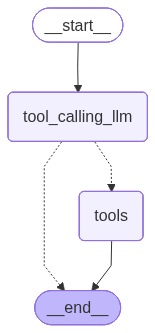

In [12]:
builder = StateGraph(State)
builder.add_node("tool_calling_llm", tool_calling_llm)
builder.add_node("tools", ToolNode(tools))

builder.add_edge(START, "tool_calling_llm")
builder.add_conditional_edges("tool_calling_llm", tools_condition)
builder.add_edge("tools", END)  # single-shot: tools → END, no loop back

graph_single = builder.compile()

try:
    display(Image(graph_single.get_graph().draw_mermaid_png()))
except Exception:
    pass

In [13]:
response = graph_single.invoke(
    {"messages": [HumanMessage(content="What is the recent AI news?")]}
)

for m in response["messages"]:
    m.pretty_print()

================================ Human Message =================================

What is the recent AI news?
================================== Ai Message ==================================
Tool Calls:
  tavily_search (h8htpszx8)
 Call ID: h8htpszx8
  Args:
    query: recent AI news
    time_range: day
    topic: news
================================= Tool Message =================================
Name: tavily_search

{"query": "recent AI news", "follow_up_questions": null, "answer": null, "images": [], "results": [{"url": "https://www.fool.com/investing/2026/06/01/nvidias-jensen-huang-just-announced-something-big/", "title": "Nvidia's Jensen Huang Just Announced Something Big - The Motley Fool", "score": 0.97068775, "published_date": "Mon, 01 Jun 2026 22:10:00 GMT", "content": "In recent years, **Nvidia** (NVDA +6.26%) has driven the artificial intelligence (AI) revolution by bringing its graphics processing units (GPUs) to data centers. As mentioned, Nvidia has built its dominance -

In [14]:
response = graph_single.invoke(
    {"messages": [HumanMessage(content="What is the latest AI research and what is 2 multiplied by 3?")]}
)

for m in response["messages"]:
    m.pretty_print()

================================ Human Message =================================

What is the latest AI research and what is 2 multiplied by 3?
================================== Ai Message ==================================
Tool Calls:
  tavily_search (33713hscm)
 Call ID: 33713hscm
  Args:
    query: latest AI research
    search_depth: advanced
    topic: general
  multiply (gvw58rfcd)
 Call ID: gvw58rfcd
  Args:
    a: 2
    b: 3
================================= Tool Message =================================
Name: tavily_search

{"query": "latest AI research", "follow_up_questions": null, "answer": null, "images": [], "results": [{"url": "https://www.ibm.com/think/news/ai-tech-trends-predictions-2026", "title": "The trends that will shape AI and tech in 2026 | IBM", "content": "### Scaling will hit its limits, and physical AI will gain momentum | Peter Staar, Principal Research Staff Member, IBM Research Zurich; Chair of the Technical Steering Committee of Docling in the Linux Fou

---
## Part 3 — ReAct Loop
### Graph: `START → tool_calling_llm ↔ tools → END`

The only difference from Part 2a: `tools → tool_calling_llm` instead of `tools → END`.

This creates a **Reason + Act (ReAct)** loop:
1. LLM reasons and decides to call a tool
2. Tool runs
3. LLM sees the tool result and either calls another tool or produces the final answer
4. `tools_condition` routes to END when no more tool calls are needed

**This is the architecture that supports multi-step reasoning.**

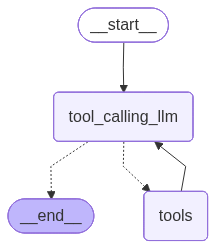

In [15]:
builder_react = StateGraph(State)
builder_react.add_node("tool_calling_llm", tool_calling_llm)
builder_react.add_node("tools", ToolNode(tools))

builder_react.add_edge(START, "tool_calling_llm")
builder_react.add_conditional_edges("tool_calling_llm", tools_condition)
builder_react.add_edge("tools", "tool_calling_llm")  # KEY CHANGE: loops back to LLM

graph_react = builder_react.compile()

try:
    display(Image(graph_react.get_graph().draw_mermaid_png()))
except Exception:
    pass

In [16]:
# Single-tool query: should trigger TavilySearch, then LLM summarises results
response = graph_react.invoke(
    {"messages": [HumanMessage(content="What is the recent AI news?")]}
)

for m in response["messages"]:
    m.pretty_print()

================================ Human Message =================================

What is the recent AI news?
================================== Ai Message ==================================
Tool Calls:
  tavily_search (fbq6dyrbg)
 Call ID: fbq6dyrbg
  Args:
    query: recent AI news
    time_range: day
    topic: news
================================= Tool Message =================================
Name: tavily_search

{"query": "recent AI news", "follow_up_questions": null, "answer": null, "images": [], "results": [{"url": "https://www.fool.com/investing/2026/06/01/nvidias-jensen-huang-just-announced-something-big/", "title": "Nvidia's Jensen Huang Just Announced Something Big - The Motley Fool", "score": 0.63804686, "published_date": "Mon, 01 Jun 2026 22:10:00 GMT", "content": "In recent years, **Nvidia** (NVDA +6.26%) has driven the artificial intelligence (AI) revolution by bringing its graphics processing units (GPUs) to data centers. As mentioned, Nvidia has built its dominance -

In [17]:
# Multi-tool query: LLM calls TavilySearch AND multiply in the same run
response = graph_react.invoke(
    {"messages": [HumanMessage(content="What is the latest AI research and what is 2 multiplied by 3?")]}
)

for m in response["messages"]:
    m.pretty_print()

================================ Human Message =================================

What is the latest AI research and what is 2 multiplied by 3?
================================== Ai Message ==================================
Tool Calls:
  tavily_search (h3jfjb6jr)
 Call ID: h3jfjb6jr
  Args:
    query: latest AI research
    search_depth: advanced
    topic: general
================================= Tool Message =================================
Name: tavily_search

{"query": "latest AI research", "follow_up_questions": null, "answer": null, "images": [], "results": [{"url": "https://www.ibm.com/think/news/ai-tech-trends-predictions-2026", "title": "The trends that will shape AI and tech in 2026 | IBM", "content": "### Scaling will hit its limits, and physical AI will gain momentum | Peter Staar, Principal Research Staff Member, IBM Research Zurich; Chair of the Technical Steering Committee of Docling in the Linux Foundation for AI and Data\n\nIBM’s Peter Staar predicts 2026 will mark 

---
## Expected Output

**Part 1 invoke:**
```
User : Hi Nexa
AI   : Hello! I'm Nexa, your AI assistant. How can I help you today?
```

**Part 3 multi-tool `pretty_print()`:**
```
================================ Human Message =================================
What is the latest AI research and what is 2 multiplied by 3?

================================== Ai Message ==================================
Tool Calls:
  tavily_search (call_abc123)
  Call ID: call_abc123
  Args:
    query: latest AI research 2025
  multiply (call_def456)
  Call ID: call_def456
  Args:
    a: 2
    b: 3

================================= Tool Message =================================
Name: tavily_search
[ ... search results ... ]

================================= Tool Message =================================
Name: multiply
6

================================== Ai Message ==================================
Here is the latest AI research ... and 2 × 3 = 6.
```

---

## Remaining Limitations

| Limitation | Notes |
|---|---|
| No conversation memory across sessions | State is in-memory only; add a checkpointer (e.g. `SqliteSaver`) for persistence |
| No streaming of tool results | `graph.stream()` yields full node outputs, not token-by-token |
| Groq models may not support all tool-calling features | Some smaller Groq models have limited parallel tool call support |
| `TavilySearch` requires a paid API key | Free tier is limited to 1000 searches/month |